<a href="https://colab.research.google.com/github/SofiaAlbyt/NM/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22%D0%9B%D0%A011_%D0%90%D0%BB%D1%8C%D0%B1%D0%B8%D1%82_%D0%A1_%D0%A1_%D0%B21_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Метод найменших квадратів (МНК)

1. Приклад 1.Наближення прямою.
Реалізація метода вручну

x = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y = [ 1.82106099  1.49670671  1.06235775  0.57080048  0.08385316 -0.33739372
 -0.64222234 -0.79829478 -0.79675842 -0.65364362]
Лінійне наближення: y = -3.1327x + 1.9037
Параболічне наближення: y = 3.5488x² + -7.0364x + 2.6844


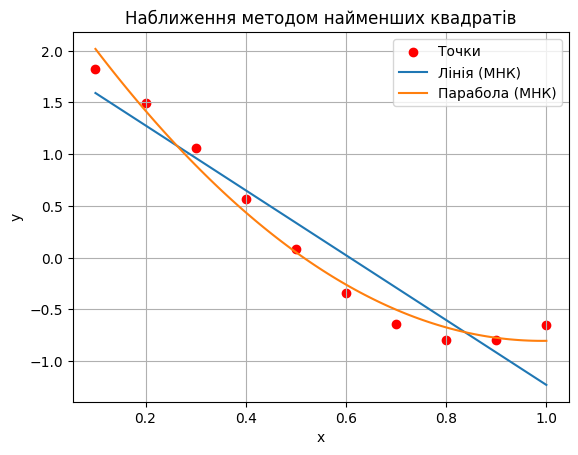

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Функція з варіанту 1
def func(x):
    return np.cos(4*x) - x + 1

# Вхідні дані
x = np.array([i * 0.1 for i in range(1, 11)])
y = np.array([func(xi) for xi in x])

print('x =', x)
print('y =', y)

n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)

a = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
b = y_mean - a * x_mean

print(f"Лінійне наближення: y = {a:.4f}x + {b:.4f}")

coeffs = np.polyfit(x, y, 2)
a2, b2, c2 = coeffs

print(f"Параболічне наближення: y = {a2:.4f}x² + {b2:.4f}x + {c2:.4f}")

x_plot = np.linspace(0.1, 1, 100)

plt.scatter(x, y, label='Точки', color='red')
plt.plot(x_plot, a*x_plot + b, label='Лінія (МНК)')
plt.plot(x_plot, a2*x_plot**2 + b2*x_plot + c2, label='Парабола (МНК)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Наближення методом найменших квадратів')
plt.legend()
plt.grid(True)

plt.show()

Приклад 2. Реалізація МНК наближення прямою за допомогою polyfit()

x = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y = [ 1.82106099  1.49670671  1.06235775  0.57080048  0.08385316 -0.33739372
 -0.64222234 -0.79829478 -0.79675842 -0.65364362]
Лінія: y = -3.1327x + 1.9037
Парабола: y = 3.5488x² + -7.0364x + 2.6844


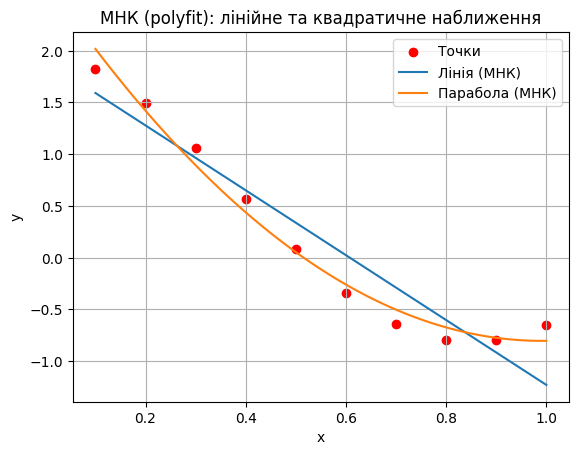

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Функція з варіанту 1
def func(x):
    return np.cos(4*x) - x + 1

# Дані
x = np.array([i * 0.1 for i in range(1, 11)])
y = np.array([func(xi) for xi in x])

print('x =', x)
print('y =', y)

coefficients_1 = np.polyfit(x, y, 1)
a, b = coefficients_1
print(f"Лінія: y = {a:.4f}x + {b:.4f}")

poly1 = np.poly1d(coefficients_1)

coefficients_2 = np.polyfit(x, y, 2)
a2, b2, c2 = coefficients_2
print(f"Парабола: y = {a2:.4f}x² + {b2:.4f}x + {c2:.4f}")

poly2 = np.poly1d(coefficients_2)

plt.scatter(x, y, color='red', label='Точки')

x_line = np.linspace(min(x), max(x), 100)

plt.plot(x_line, poly1(x_line), label='Лінія (МНК)')
plt.plot(x_line, poly2(x_line), label='Парабола (МНК)')

plt.title('МНК (polyfit): лінійне та квадратичне наближення')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()

Приклад 3  Реалізація МНК наближення параболою за допомогою polyfit()

x = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y = [ 1.82106099  1.49670671  1.06235775  0.57080048  0.08385316 -0.33739372
 -0.64222234 -0.79829478 -0.79675842 -0.65364362]
Рівняння параболи: y = 3.5488x^2 + -7.0364x + 2.6844


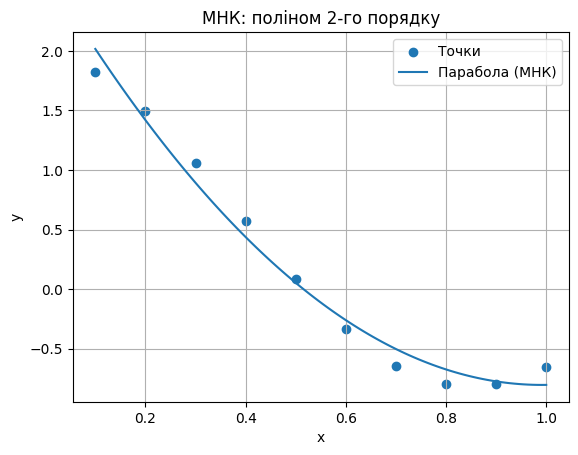

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Функція з варіанту 1
def func(x):
    return np.cos(4*x) - x + 1

x = np.array([i * 0.1 for i in range(1, 11)])
y = np.array([func(xi) for xi in x])

print('x =', x)
print('y =', y)

# Поліном 2-го порядку
coefficients = np.polyfit(x, y, 2)

a, b, c = coefficients
print(f"Рівняння параболи: y = {a:.4f}x^2 + {b:.4f}x + {c:.4f}")

polynomial = np.poly1d(coefficients)

# Графік
plt.scatter(x, y, label='Точки')
x_line = np.linspace(min(x), max(x), 100)
plt.plot(x_line, polynomial(x_line), label='Парабола (МНК)')

plt.title('МНК: поліном 2-го порядку')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()

Приклад 4. Наближення параболою за допомогою least_squares ()

x = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y = [ 1.82106099  1.49670671  1.06235775  0.57080048  0.08385316 -0.33739372
 -0.64222234 -0.79829478 -0.79675842 -0.65364362]
Парабола: y = 3.5488x^2 + -7.0364x + 2.6844


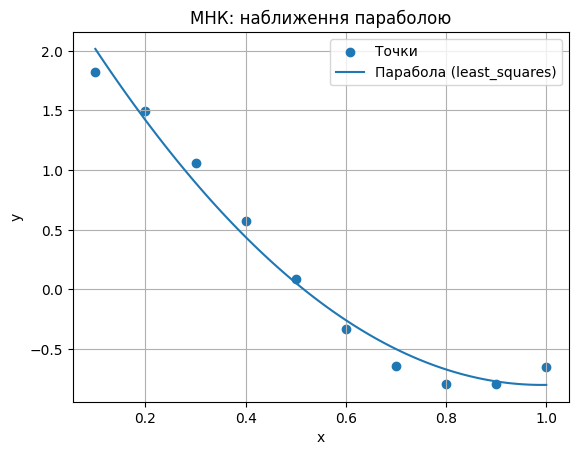

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Функція з варіанту 1
def func(x):
    return np.cos(4*x) - x + 1

# Дані
x = np.array([i * 0.1 for i in range(1, 11)])
y = np.array([func(xi) for xi in x])

print('x =', x)
print('y =', y)

# Функція залишків (для МНК)
def fun(a, x, y):
    return a[0] + a[1] * x + a[2] * x**2 - y

# Початкове наближення
a0 = np.array([1, 1, 1])

# Розв'язання
res_lsq = least_squares(fun, x0=a0, args=(x, y))

a0_res, a1_res, a2_res = res_lsq.x
print(f"Парабола: y = {a2_res:.4f}x^2 + {a1_res:.4f}x + {a0_res:.4f}")

# Апроксимаційна функція
def f(x):
    return a0_res + a1_res * x + a2_res * x**2

# Графік
x_p = np.linspace(min(x), max(x), 100)
y_p = f(x_p)

plt.scatter(x, y, label='Точки')
plt.plot(x_p, y_p, label='Парабола (least_squares)')

plt.title("МНК: наближення параболою")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()